<a href="https://colab.research.google.com/github/u7792930/ESMC2010-W10-GroupProject/blob/main/EMSC2010_Group_Project_Week_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project Week 10

## 1. Project Overview
Group name: Precipitation Pirates

Project week: 10

Project title: Yass River Water Level and Discharge through time

Datasets used (name and source): 'Yass River at Yass' https://www.bom.gov.au/waterdata/


## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Lee | Khai | Yes/Partial/No| Add note|
| Data steward | Khai | Juliet | Yes/Partial/No| Add note|
| Analysis / modelling | Juliet | Binyao | Yes/Partial/No| Add note|
| Visualisation / interpretation | Binyao | Kedi | Yes/Partial/No| Add note|
| Narrative | Kedi | Lee | Yes/Partial/No| Add note|
| Quality Control / Reproducibility  | Name | Name | Yes/Partial/No/`NA`| Add note|




## 3. Deputy Interventions

* Role affected: Data Steward

* Reason (e.g. missed deadline, absence, etc.): unknown.

* Deputy action taken: Found and cleaned dataset for analysis

* Impact on workflow: Had more work than expected to do with limited time, but it was completed before the end of the analyst deadline, so it did not impact the rest of the group.

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

In [ ]:
import pandas as pd #for data import
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

In [ ]:
df_discharge = pd.read_csv('WaterDischarge.csv', skiprows=10, header=None, sep=',', names=['Timestamp', 'Discharge_Value', 'Quality Code', 'Interpolation Type'])
df_discharge = df_discharge.drop(columns=['Quality Code', 'Interpolation Type'])
df_discharge = df_discharge.dropna(subset=['Discharge_Value'])
df_discharge.head()

,Timestamp,Discharge_Value
1,1915-08-24T22:00:00.000+10:00,33.593
2,1915-08-25T09:00:00.000+10:00,10.054
3,1915-08-26T09:00:00.000+10:00,9.817
4,1915-08-27T09:00:00.000+10:00,9.817
5,1915-08-28T09:00:00.000+10:00,0.953


In [ ]:
df_level = pd.read_csv('WaterLevel1.csv', skiprows=10, header=None, sep=',', names=['Timestamp', 'Level_Value', 'Quality Code', 'Interpolation Type'])
df_level = df_level.drop(columns=['Quality Code', 'Interpolation Type'])
df_level = df_level.dropna(subset=['Level_Value'])
df_level.head()

,Timestamp,Level_Value
1,1915-08-24T22:00:00.000+10:00,1.830
2,1915-08-25T09:00:00.000+10:00,1.027
3,1915-08-26T09:00:00.000+10:00,1.015
4,1915-08-27T09:00:00.000+10:00,1.015
5,1915-08-28T09:00:00.000+10:00,0.405


In [ ]:
# Convert 'Timestamp' column to datetime objects in both DataFrames
df_discharge['Timestamp'] = pd.to_datetime(df_discharge['Timestamp'])
df_level['Timestamp'] = pd.to_datetime(df_level['Timestamp'])

# Merge the two dataframes on 'Timestamp' with an inner join
df_merged = pd.merge(df_discharge, df_level, on='Timestamp', how='inner')

# Display the head of the merged dataframe
display(df_merged.head())

,Timestamp,Discharge_Value,Level_Value
0,1915-08-24 22:00:00+10:00,33.593,1.830
1,1915-08-25 09:00:00+10:00,10.054,1.027
2,1915-08-26 09:00:00+10:00,9.817,1.015
3,1915-08-27 09:00:00+10:00,9.817,1.015
4,1915-08-28 09:00:00+10:00,0.953,0.405


In [ ]:
#Merging and averaging multiple values from the same day

# Convert Timestamp to Month-Year period
df_merged['Month_Year'] = df_merged['Timestamp'].dt.to_period('M')

# Group by Month-Year and calculate mean
df_monthly_mean = df_merged.groupby('Month_Year')[['Discharge_Value', 'Level_Value']].mean().reset_index()

# Convert Month_Year Period back to the start of the month as datetime for plotting
df_monthly_mean['Date'] = df_monthly_mean['Month_Year'].dt.start_time

# Drop the 'Month_Year' column as 'Date' now serves the purpose
df_monthly_mean = df_monthly_mean.drop(columns=['Month_Year'])

display(df_monthly_mean.head())

/tmp/ipykernel_4200/3082308453.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_merged['Month_Year'] = df_merged['Timestamp'].dt.to_period('M')


,Discharge_Value,Level_Value,Date
0,8.287125,0.805875,1915-08-01
1,28.053680,1.303120,1915-09-01
2,3.731150,0.580200,1915-10-01
3,0.793667,0.393000,1915-11-01
4,3.720619,0.567190,1915-12-01


graphs inital

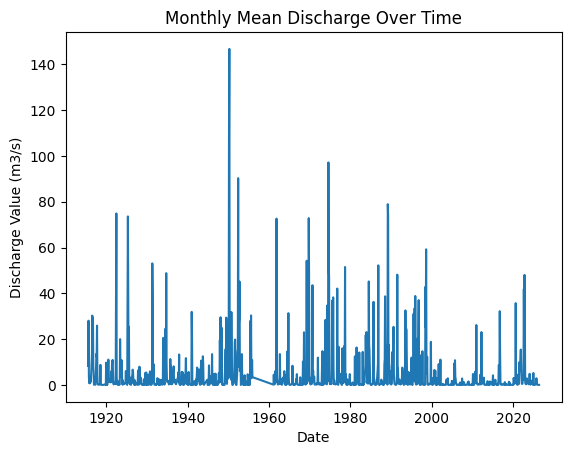

In [ ]:
plt.plot(df_monthly_mean['Date'], df_monthly_mean['Discharge_Value'], label='Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge Value (m3/s)')
plt.title('Monthly Mean Discharge Over Time')
plt.show()

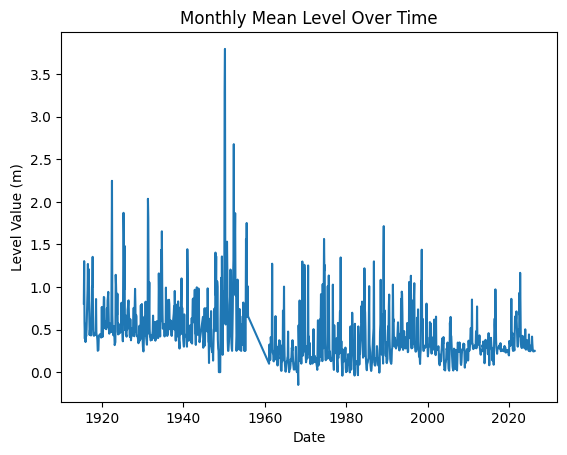

In [ ]:
plt.plot(df_monthly_mean['Date'], df_monthly_mean['Level_Value'], label='Level')
plt.xlabel('Date')
plt.ylabel('Level Value (m)')
plt.title('Monthly Mean Level Over Time')
plt.show()

##Discharge
detrending, moving average

In [ ]:
import matplotlib.dates as mdates

# Calculate months since the first date
first_date = df_monthly_mean['Date'].min()
date_num = (df_monthly_mean['Date'] - first_date).dt.days / 30.4375 # Approximate days in a month
date_norm = df_monthly_mean['Date']

discharge = df_monthly_mean['Discharge_Value']

In [ ]:
level = df_monthly_mean['Level_Value']

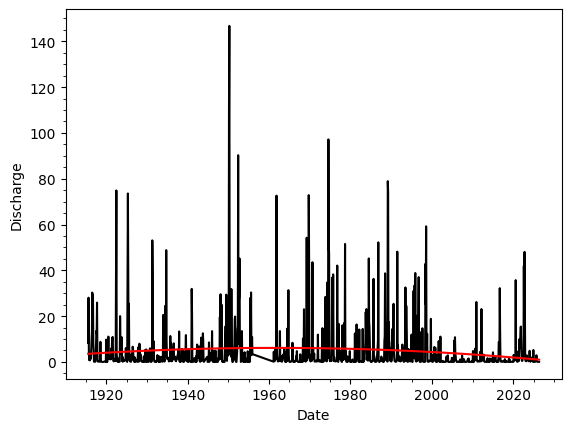

In [ ]:
order = 2
 #set the polynomial order
pp = np.polyfit(date_num, discharge, order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp, date_num) #find the value of the polynomial at each time point.

plt.plot(date_norm, discharge, 'k') #plot the data using original dates for x-axis for better readability
plt.plot(date_norm, trend, 'r') #plot the trend using original dates for x-axis
plt.xlabel('Date') #label the x-axis
plt.ylabel('Discharge') #label the y-axis
plt.minorticks_on() #add minorticks

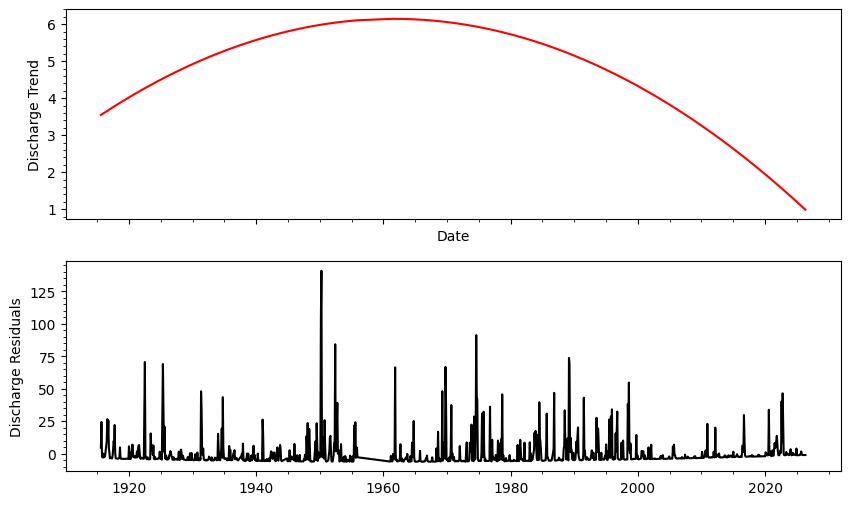

In [ ]:
residuals = discharge - trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(date_norm,trend,'r') #plot the polynomial trend
axes[1].plot(date_norm,residuals,'k') #plot the residuals

axes[0].set_xlabel('Date') #label the x-axis
axes[0].set_ylabel('Discharge Trend') #label the trend y-axis
axes[1].set_ylabel('Discharge Residuals') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

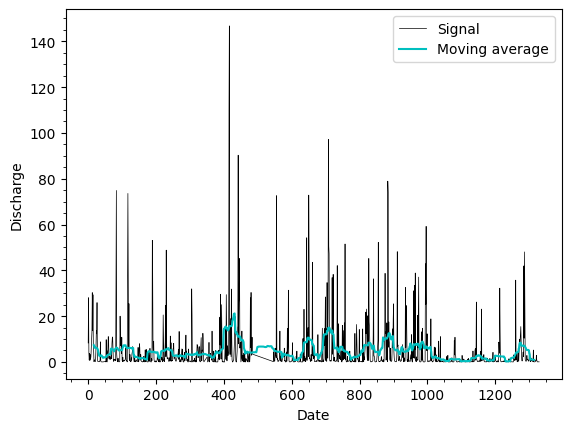

In [ ]:

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w


w = 31 #length of the moving average
ys = moving_average(discharge, w) #process the signal
ts = moving_average(date_num, w) #process the times


plt.plot(date_num,discharge,'k',linewidth=0.5,label='Signal') #plot the noisy signal
plt.plot(ts,ys,'c',label='Moving average') #plot the moving average
plt.xlabel('Date') #label the x-axis
plt.ylabel('Discharge') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks


In [ ]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqscutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time, signal, cutoff): # cutoff is a list/tuple [low_freq, high_freq]
    n = len(time)
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1 / sample_rate)

    # Zero out frequencies outside the band
    fft_vals[(freqs < cutoff[0]) | (freqs > cutoff[1])] = 0.0

    filtered_signal = np.fft.irfft(fft_vals, n=len(time))
    return x, filtered_signal

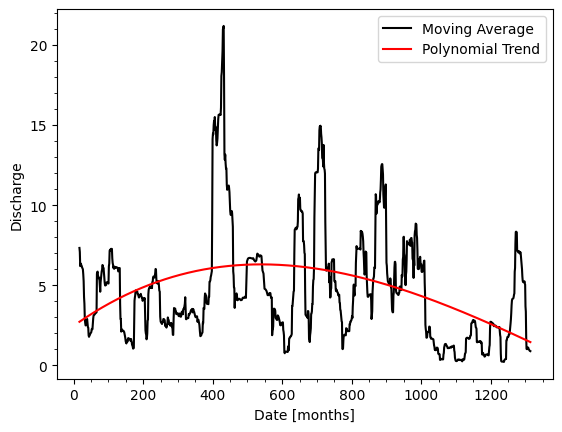

In [ ]:
pp = np.polyfit(ts,ys,3) #fit a trendline to the moving average
plt.plot(ts,ys,'k', label='Moving Average') #plot the moving average data
plt.plot(ts,np.polyval(pp,ts),'r', label='Polynomial Trend') #plot the trendline of the moving average
plt.xlabel('Date [months]') #label the x-axis
plt.ylabel('Discharge') #label the y-axis
plt.legend()
plt.minorticks_on() #add minorticks

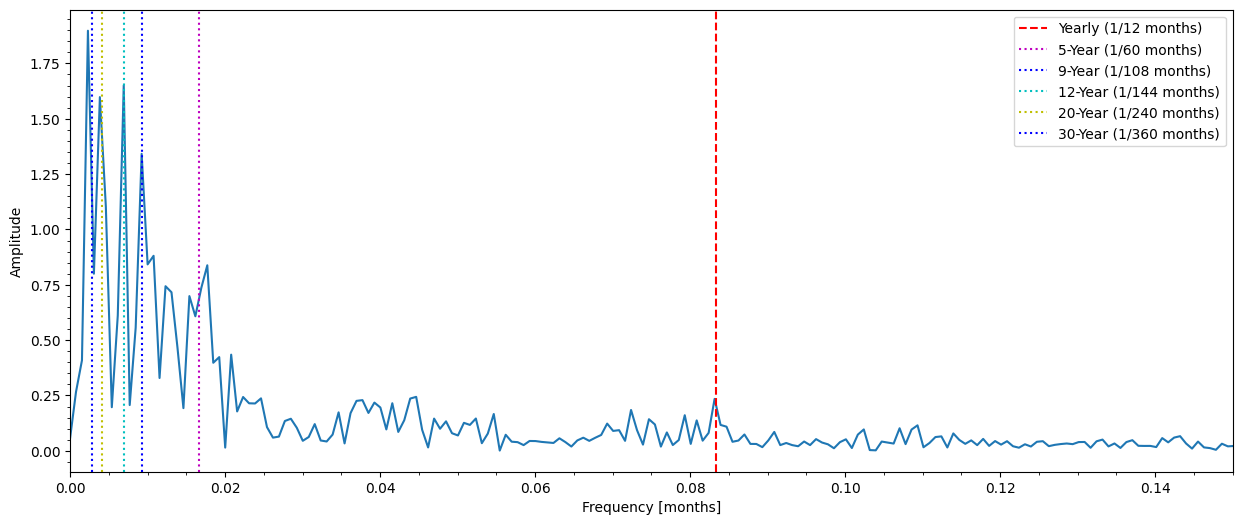

In [ ]:
detrend = ys-np.polyval(pp,ts) #calculate the detrended moving average data
freqs, amps = freq_spectrum(ts,detrend) #frequency spectrum of the detrended moving average
plt.figure(figsize=(15, 6)) # Make the figure wider
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [months]') #label the x-axis
plt.xlim(0,0.15)
plt.ylabel('Amplitude') #label the y-axis
plt.minorticks_on() #add minorticks

#frequency marks
plt.gca().axvline(x=1/12,color='r', linestyle='--', label='Yearly (1/12 months)') # Yearly cycle
plt.gca().axvline(x=1/60,color='m', linestyle=':', label='5-Year (1/60 months)') # 5-Year cycle
plt.gca().axvline(x=1/108,color='b', linestyle=':', label='9-Year (1/108 months)') # 9-Year cycle
plt.gca().axvline(x=1/144,color='c', linestyle=':', label='12-Year (1/144 months)') # 12-Year cycle
plt.gca().axvline(x=1/240,color='y', linestyle=':', label='20-Year (1/240 months)') # 20-Year cycle
plt.gca().axvline(x=1/360,color='b', linestyle=':', label='30-Year (1/360 months)') # 30-Year cycle
plt.legend()

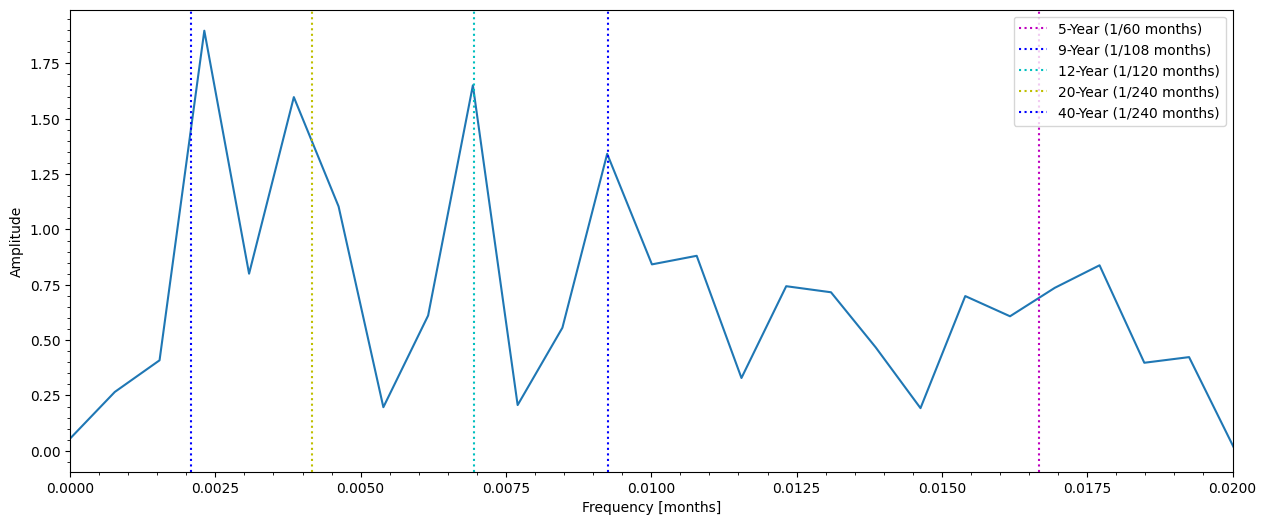

In [ ]:
plt.figure(figsize=(15, 6)) # Make the figure wider
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [months]') #label the x-axis
plt.xlim(0,0.02)
plt.ylabel('Amplitude') #label the y-axis
plt.minorticks_on() #add minorticks

#frequency marks, assuming significant frequencies
plt.gca().axvline(x=1/60,color='m', linestyle=':', label='5-Year (1/60 months)') # 5-Year cycle
plt.gca().axvline(x=1/108,color='b', linestyle=':', label='9-Year (1/108 months)') # 9-Year cycle
plt.gca().axvline(x=1/144,color='c', linestyle=':', label='12-Year (1/120 months)') # 12-Year cycle
plt.gca().axvline(x=1/240,color='y', linestyle=':', label='20-Year (1/240 months)') # 20-Year cycle
plt.gca().axvline(x=1/480,color='b', linestyle=':', label='40-Year (1/240 months)') # 40-Year cycle
plt.legend()

In [ ]:

import matplotlib.dates as mdates

first_date_dt = df_monthly_mean['Date'].min()

def num_to_datetime(num_time_array, first_date_dt):
    # This conversion assumes date_num is (date - first_date).dt.days / 30.4375
    # So to reverse, num_time_array * 30.4375 gives days since first_date
    return first_date_dt + pd.to_timedelta(num_time_array * 30.4375, unit='days')

# Define a small bandwidth for the bandpass filter
delta_freq = 0.001 # cycles/month - Adjusted for better visualization

# Discharge frequencies and their labels
discharge_cycles = {
    'Yearly': 1/12,
    '5-Year': 1/60,
    '9-Year': 1/108,
    '12-Year': 1/144,
    '20-Year': 1/240,
    '30-Year': 1/360,
}

# Water Level frequencies and their labels
level_cycles = {
    'Yearly': 1/12,
    '5-Year': 1/60,
    '9-Year': 1/108,
    '12-Year': 1/144,
    '20-Year': 1/240,
    '40-Year': 1/480,
}


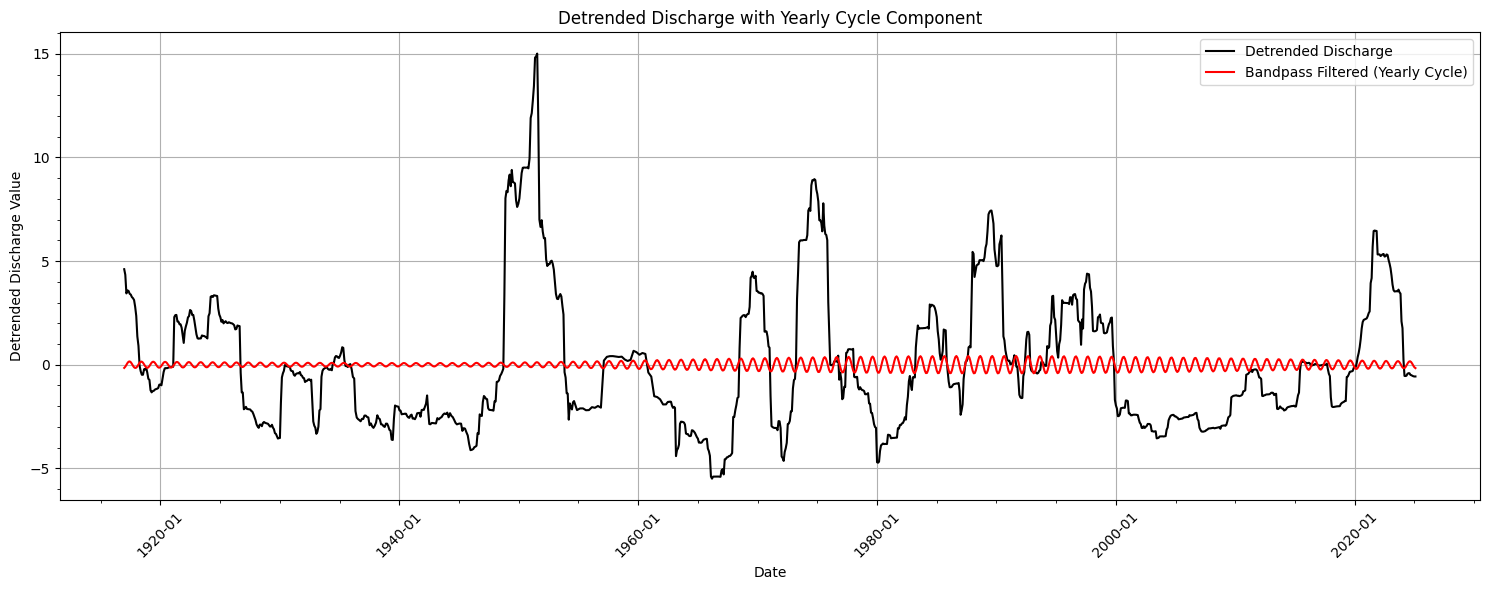

In [ ]:

# Bandpass filter for Discharge: Yearly Cycle
low_freq_discharge = discharge_cycles['Yearly'] - delta_freq
high_freq_discharge = discharge_cycles['Yearly'] + delta_freq
filtered_x_discharge, filtered_signal_discharge = bandpass_filter(ts, detrend, [low_freq_discharge, high_freq_discharge])

plot_ts_dt_discharge = num_to_datetime(ts, first_date_dt)
plot_filtered_x_dt_discharge = num_to_datetime(filtered_x_discharge, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_discharge, detrend, 'k-', label='Detrended Discharge')
plt.plot(plot_filtered_x_dt_discharge, filtered_signal_discharge, 'r-', label='Bandpass Filtered (Yearly Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Discharge Value')
plt.title('Detrended Discharge with Yearly Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


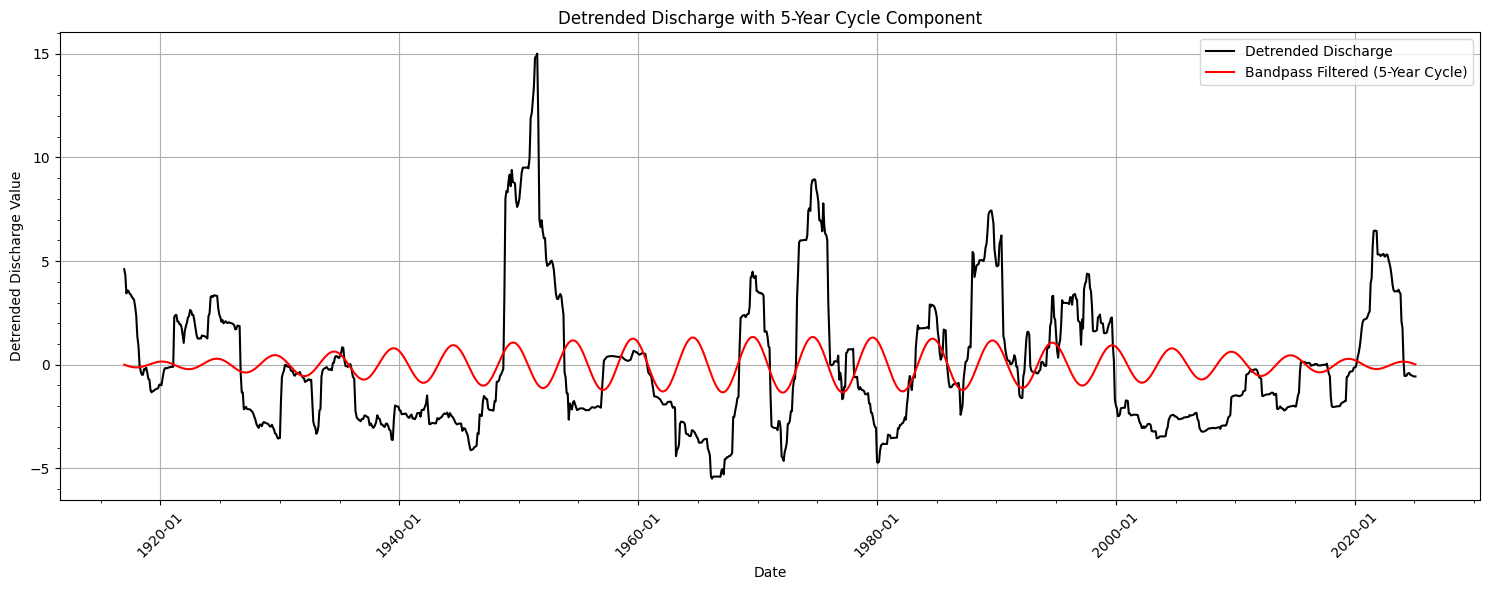

In [ ]:

# Bandpass filter for Discharge: 5-Year Cycle
low_freq_discharge = discharge_cycles['5-Year'] - delta_freq
high_freq_discharge = discharge_cycles['5-Year'] + delta_freq
filtered_x_discharge, filtered_signal_discharge = bandpass_filter(ts, detrend, [low_freq_discharge, high_freq_discharge])

plot_ts_dt_discharge = num_to_datetime(ts, first_date_dt)
plot_filtered_x_dt_discharge = num_to_datetime(filtered_x_discharge, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_discharge, detrend, 'k-', label='Detrended Discharge')
plt.plot(plot_filtered_x_dt_discharge, filtered_signal_discharge, 'r-', label='Bandpass Filtered (5-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Discharge Value')
plt.title('Detrended Discharge with 5-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


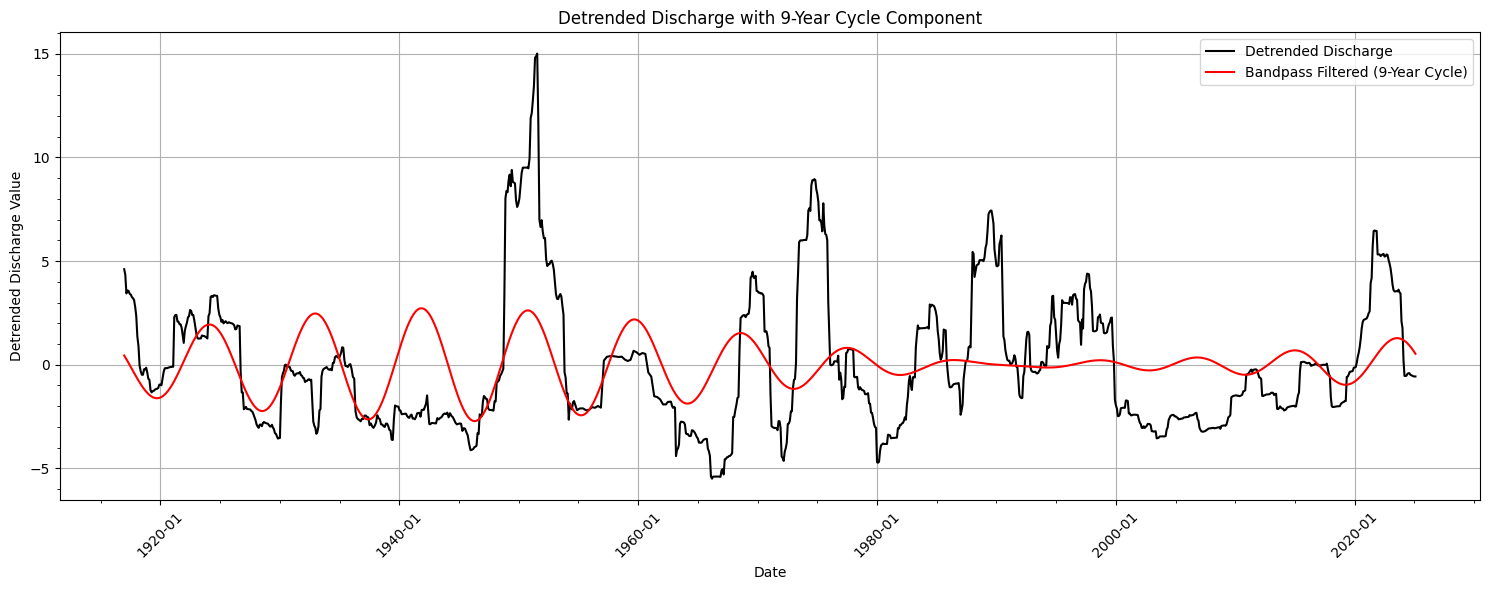

In [ ]:

# Bandpass filter for Discharge: 9-Year Cycle
low_freq_discharge = discharge_cycles['9-Year'] - delta_freq
high_freq_discharge = discharge_cycles['9-Year'] + delta_freq
filtered_x_discharge, filtered_signal_discharge = bandpass_filter(ts, detrend, [low_freq_discharge, high_freq_discharge])

plot_ts_dt_discharge = num_to_datetime(ts, first_date_dt)
plot_filtered_x_dt_discharge = num_to_datetime(filtered_x_discharge, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_discharge, detrend, 'k-', label='Detrended Discharge')
plt.plot(plot_filtered_x_dt_discharge, filtered_signal_discharge, 'r-', label='Bandpass Filtered (9-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Discharge Value')
plt.title('Detrended Discharge with 9-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


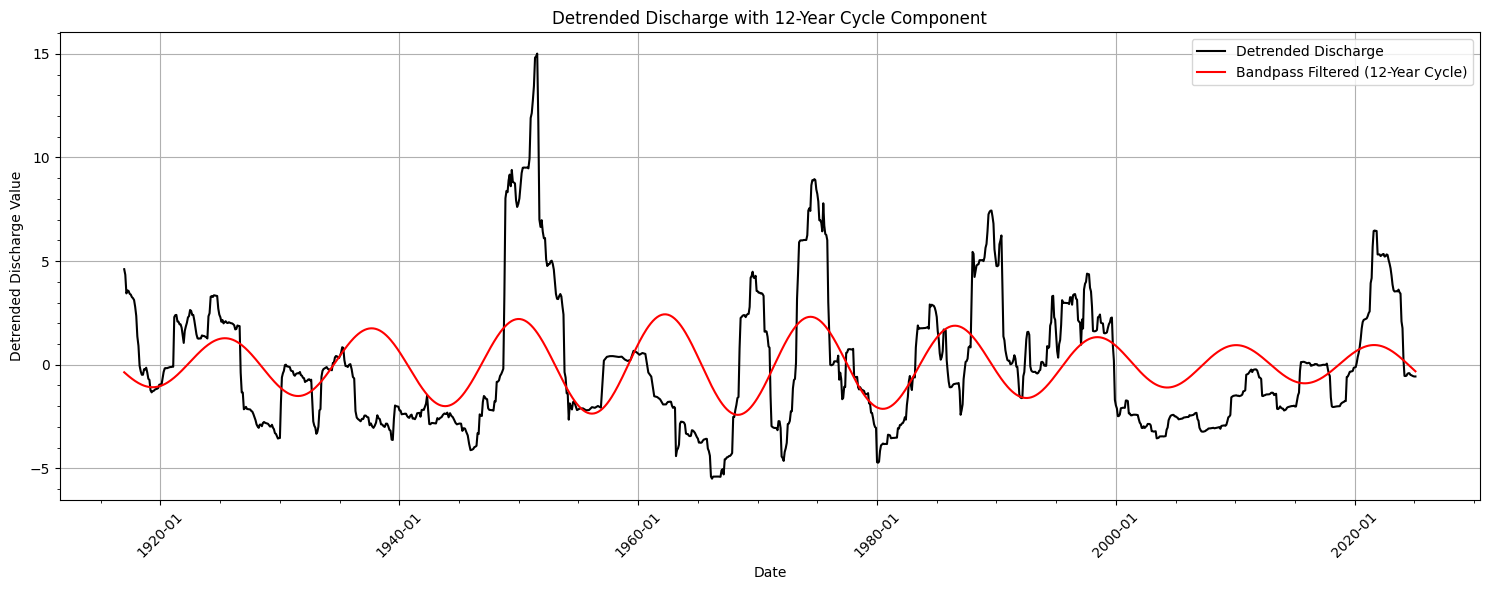

In [ ]:

# Bandpass filter for Discharge: 12-Year Cycle
low_freq_discharge = discharge_cycles['12-Year'] - delta_freq
high_freq_discharge = discharge_cycles['12-Year'] + delta_freq
filtered_x_discharge, filtered_signal_discharge = bandpass_filter(ts, detrend, [low_freq_discharge, high_freq_discharge])

plot_ts_dt_discharge = num_to_datetime(ts, first_date_dt)
plot_filtered_x_dt_discharge = num_to_datetime(filtered_x_discharge, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_discharge, detrend, 'k-', label='Detrended Discharge')
plt.plot(plot_filtered_x_dt_discharge, filtered_signal_discharge, 'r-', label='Bandpass Filtered (12-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Discharge Value')
plt.title('Detrended Discharge with 12-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


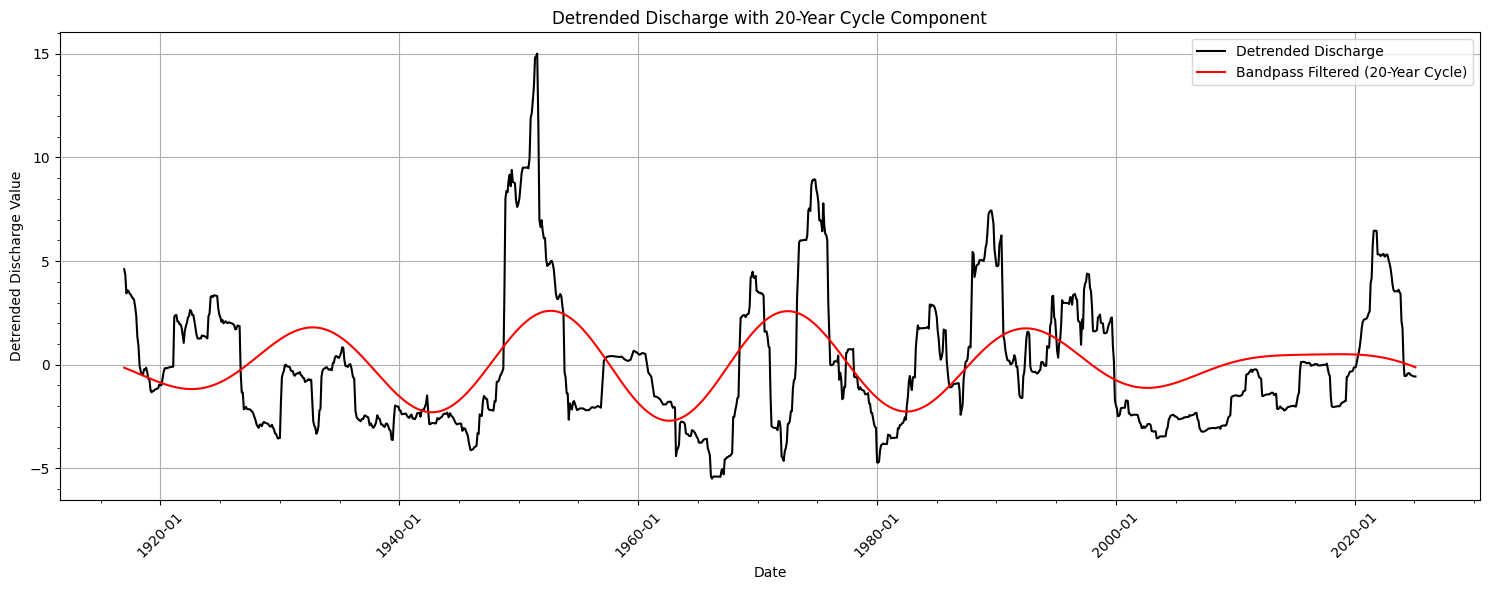

In [ ]:

# Bandpass filter for Discharge: 20-Year Cycle
low_freq_discharge = discharge_cycles['20-Year'] - delta_freq
high_freq_discharge = discharge_cycles['20-Year'] + delta_freq
filtered_x_discharge, filtered_signal_discharge = bandpass_filter(ts, detrend, [low_freq_discharge, high_freq_discharge])

plot_ts_dt_discharge = num_to_datetime(ts, first_date_dt)
plot_filtered_x_dt_discharge = num_to_datetime(filtered_x_discharge, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_discharge, detrend, 'k-', label='Detrended Discharge')
plt.plot(plot_filtered_x_dt_discharge, filtered_signal_discharge, 'r-', label='Bandpass Filtered (20-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Discharge Value')
plt.title('Detrended Discharge with 20-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


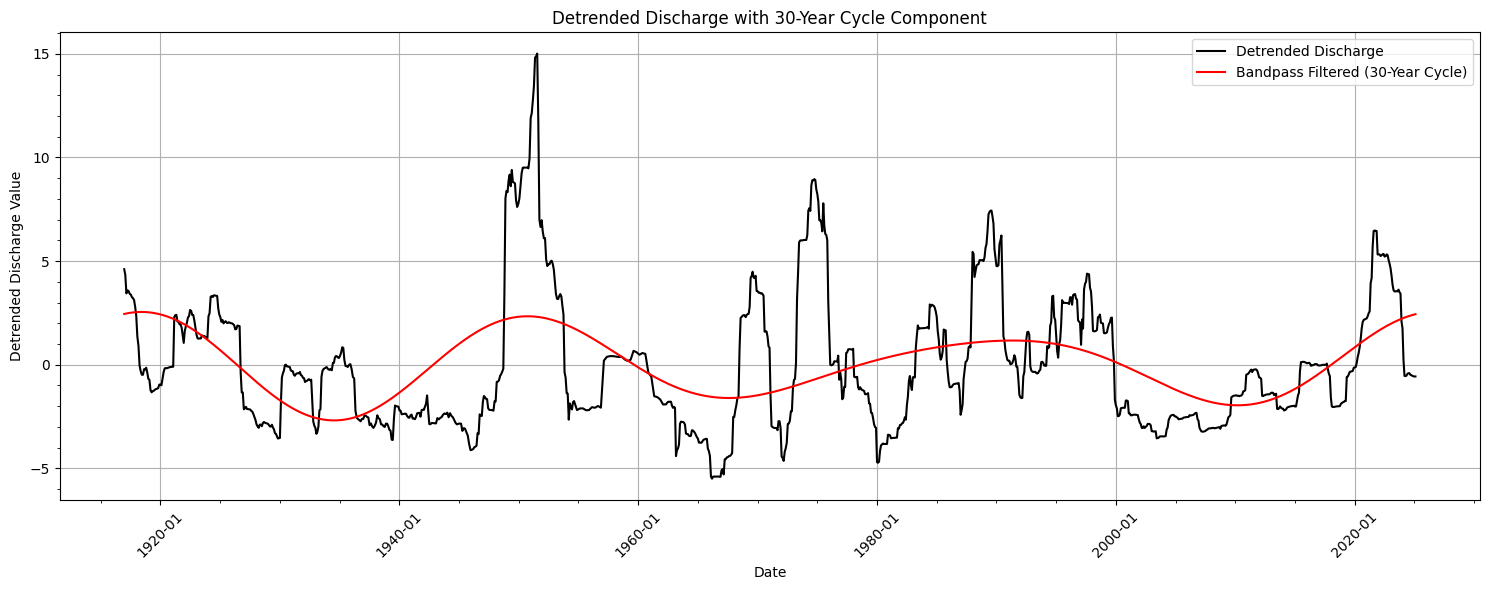

In [ ]:

# Bandpass filter for Discharge: 30-Year Cycle
low_freq_discharge = discharge_cycles['30-Year'] - delta_freq
high_freq_discharge = discharge_cycles['30-Year'] + delta_freq
filtered_x_discharge, filtered_signal_discharge = bandpass_filter(ts, detrend, [low_freq_discharge, high_freq_discharge])

plot_ts_dt_discharge = num_to_datetime(ts, first_date_dt)
plot_filtered_x_dt_discharge = num_to_datetime(filtered_x_discharge, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_discharge, detrend, 'k-', label='Detrended Discharge')
plt.plot(plot_filtered_x_dt_discharge, filtered_signal_discharge, 'r-', label='Bandpass Filtered (30-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Discharge Value')
plt.title('Detrended Discharge with 30-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##Water Level

In [ ]:
level = df_monthly_mean['Level_Value']

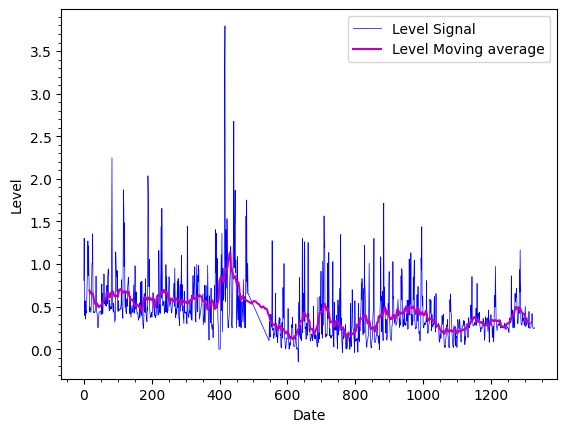

In [ ]:
w_level = 31 #length of the moving average, assuming same as discharge
ys_level = moving_average(level, w_level) #process the level signal
ts_level = moving_average(date_num, w_level) #process the times for level (will be same as ts)

plt.plot(date_num,level,'b',linewidth=0.5,label='Level Signal') #plot the noisy level signal
plt.plot(ts_level,ys_level,'m',label='Level Moving average') #plot the moving average of level
plt.xlabel('Date') #label the x-axis
plt.ylabel('Level') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks

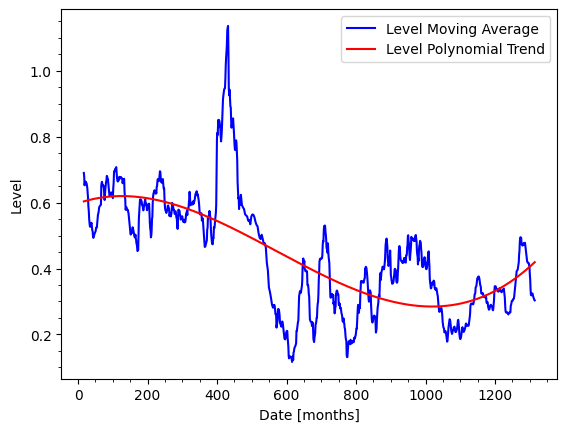

In [ ]:
pp_level = np.polyfit(ts_level,ys_level,3) #fit a trendline to the moving average of level
plt.plot(ts_level,ys_level,'b', label='Level Moving Average') #plot the moving average data
plt.plot(ts_level,np.polyval(pp_level,ts_level),'r', label='Level Polynomial Trend') #plot the trendline of the moving average
plt.xlabel('Date [months]') #label the x-axis
plt.ylabel('Level') #label the y-axis
plt.legend()
plt.minorticks_on() #add minorticks

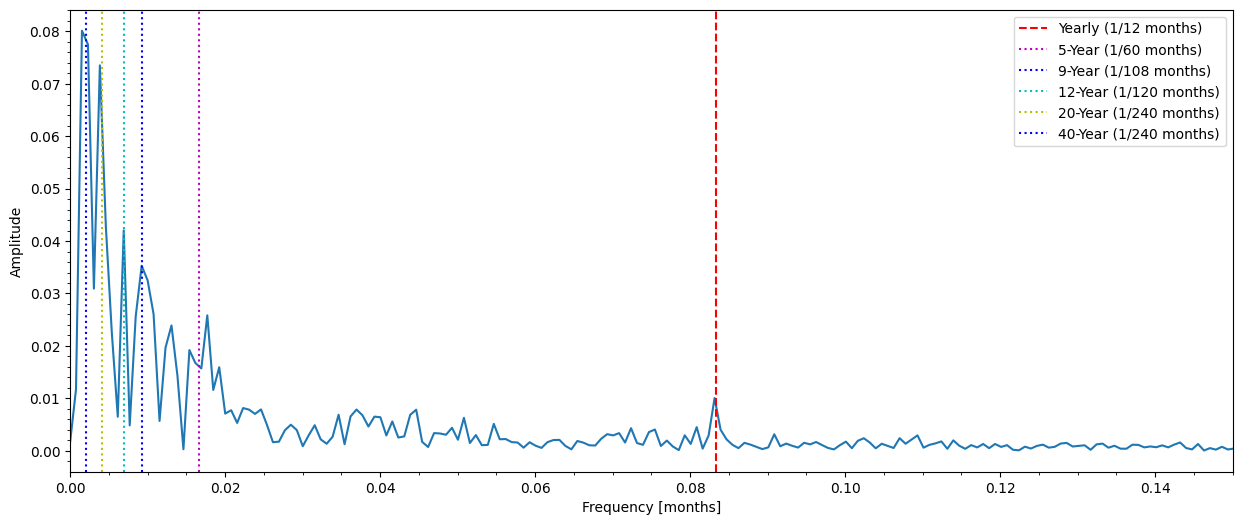

In [ ]:
detrend_level = ys_level-np.polyval(pp_level,ts_level) #calculate the detrended moving average level data
freqs_level, amps_level = freq_spectrum(ts_level,detrend_level) #frequency spectrum of the detrended moving average level
plt.figure(figsize=(15, 6)) # Make the figure wider
plt.plot(freqs_level,amps_level) #plot the frequency spectrum
plt.xlabel('Frequency [months]') #label the x-axis
plt.xlim(0,0.15)
plt.ylabel('Amplitude') #label the y-axis
plt.minorticks_on() #add minorticks

#frequency marks, assuming significant frequencies
plt.gca().axvline(x=1/12,color='r', linestyle='--', label='Yearly (1/12 months)') # Yearly cycle
plt.gca().axvline(x=1/60,color='m', linestyle=':', label='5-Year (1/60 months)') # 5-Year cycle
plt.gca().axvline(x=1/108,color='b', linestyle=':', label='9-Year (1/108 months)') # 9-Year cycle
plt.gca().axvline(x=1/144,color='c', linestyle=':', label='12-Year (1/120 months)') # 12-Year cycle
plt.gca().axvline(x=1/240,color='y', linestyle=':', label='20-Year (1/240 months)') # 20-Year cycle
plt.gca().axvline(x=1/480,color='b', linestyle=':', label='40-Year (1/240 months)') # 40-Year cycle
plt.legend()

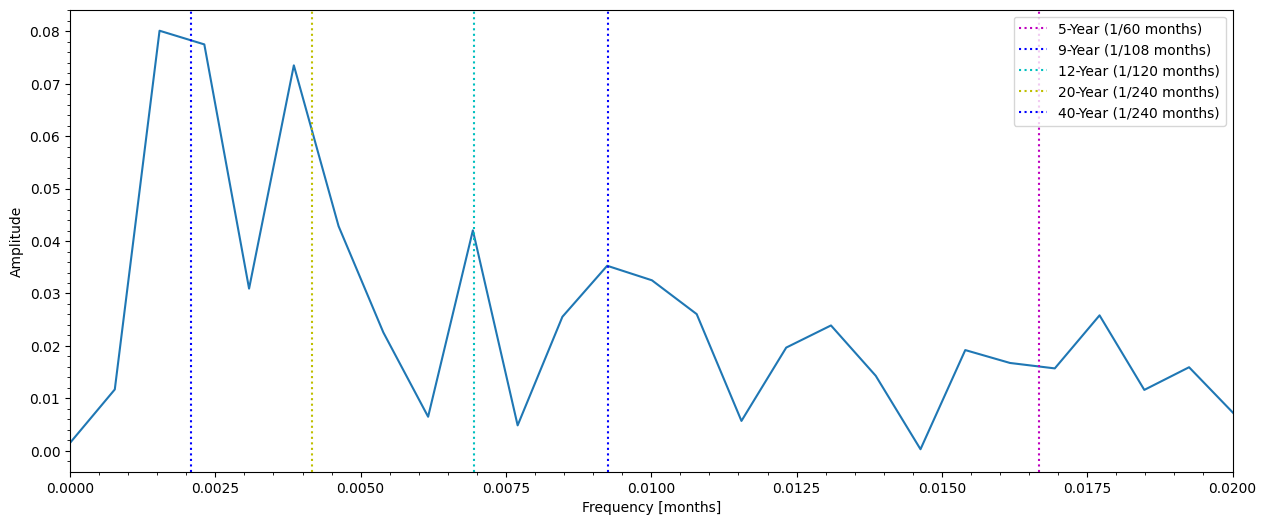

In [ ]:
plt.figure(figsize=(15, 6)) # Make the figure wider
plt.plot(freqs_level,amps_level) #plot the frequency spectrum
plt.xlabel('Frequency [months]') #label the x-axis
plt.xlim(0,0.02)
plt.ylabel('Amplitude') #label the y-axis
plt.minorticks_on() #add minorticks

#frequency marks, assuming significant frequencies
plt.gca().axvline(x=1/60,color='m', linestyle=':', label='5-Year (1/60 months)') # 5-Year cycle
plt.gca().axvline(x=1/108,color='b', linestyle=':', label='9-Year (1/108 months)') # 9-Year cycle
plt.gca().axvline(x=1/144,color='c', linestyle=':', label='12-Year (1/120 months)') # 12-Year cycle
plt.gca().axvline(x=1/240,color='y', linestyle=':', label='20-Year (1/240 months)') # 20-Year cycle
plt.gca().axvline(x=1/480,color='b', linestyle=':', label='40-Year (1/240 months)') # 40-Year cycle
plt.legend()

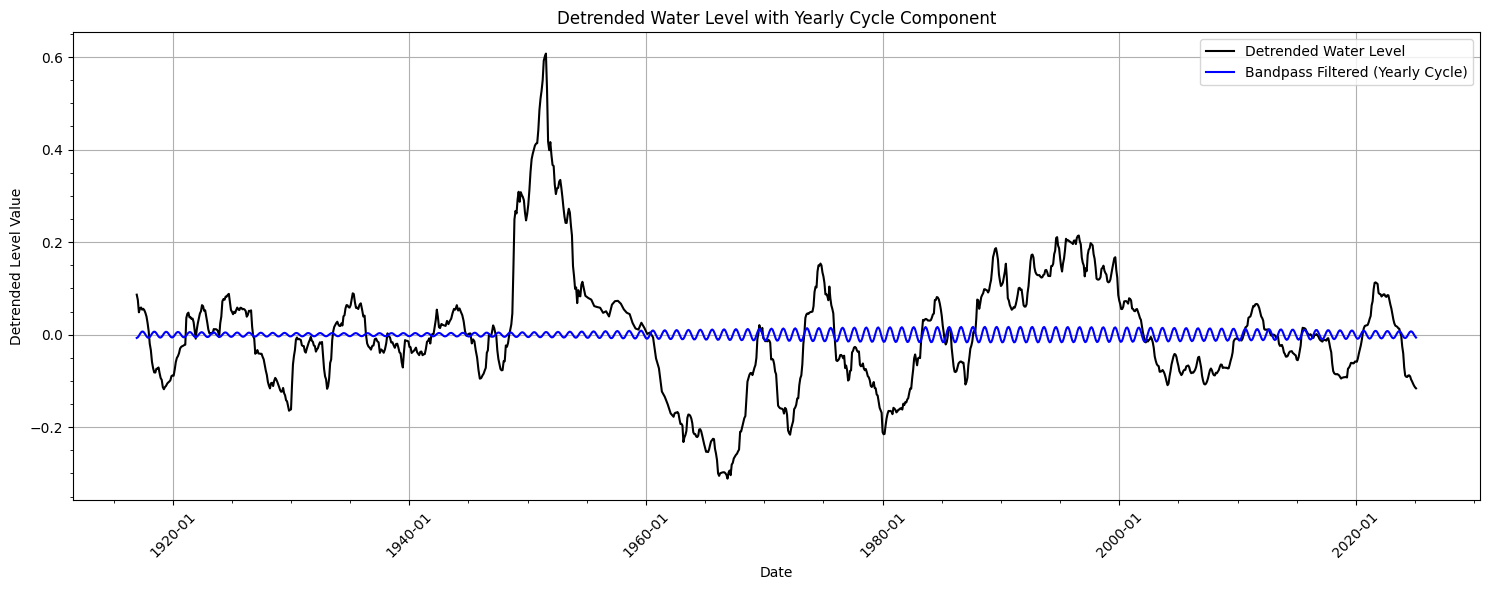

In [ ]:

# Bandpass filter for Water Level: Yearly Cycle
low_freq_level = level_cycles['Yearly'] - delta_freq
high_freq_level = level_cycles['Yearly'] + delta_freq
filtered_x_level, filtered_signal_level = bandpass_filter(ts_level, detrend_level, [low_freq_level, high_freq_level])

plot_ts_dt_level = num_to_datetime(ts_level, first_date_dt)
plot_filtered_x_dt_level = num_to_datetime(filtered_x_level, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_level, detrend_level, 'k-', label='Detrended Water Level')
plt.plot(plot_filtered_x_dt_level, filtered_signal_level, 'b-', label='Bandpass Filtered (Yearly Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Level Value')
plt.title('Detrended Water Level with Yearly Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


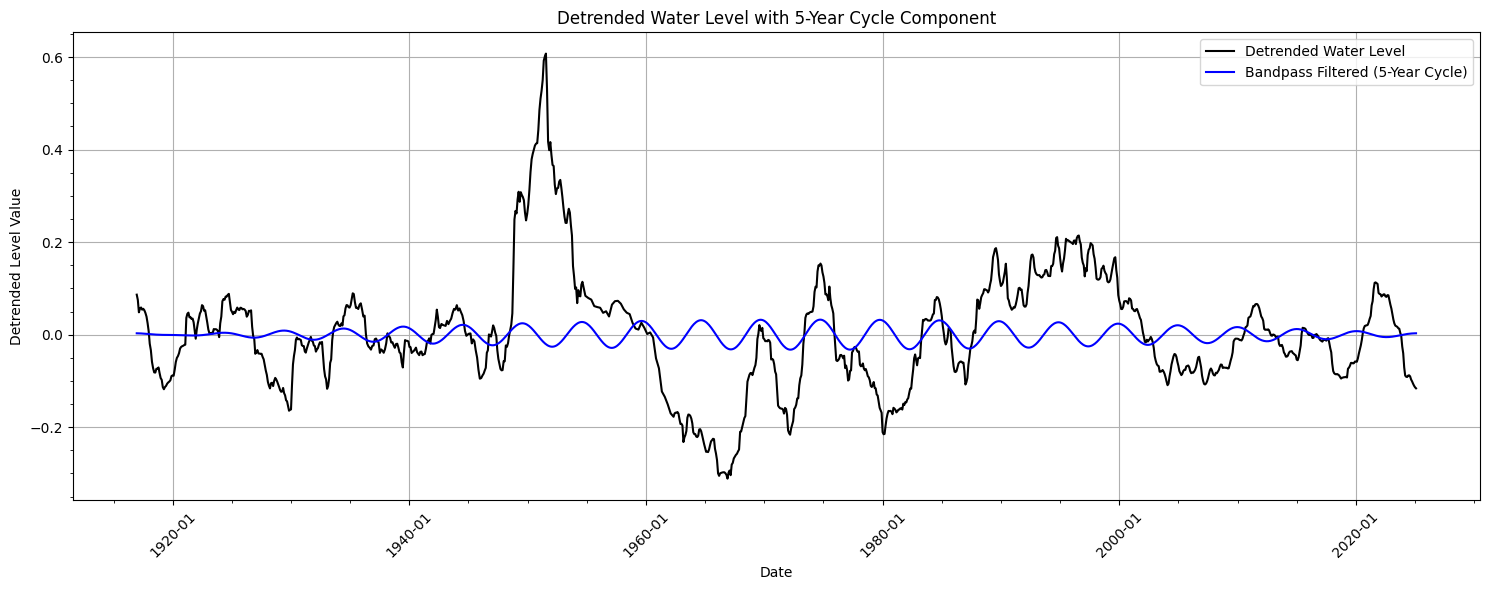

In [ ]:

# Bandpass filter for Water Level: 5-Year Cycle
low_freq_level = level_cycles['5-Year'] - delta_freq
high_freq_level = level_cycles['5-Year'] + delta_freq
filtered_x_level, filtered_signal_level = bandpass_filter(ts_level, detrend_level, [low_freq_level, high_freq_level])

plot_ts_dt_level = num_to_datetime(ts_level, first_date_dt)
plot_filtered_x_dt_level = num_to_datetime(filtered_x_level, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_level, detrend_level, 'k-', label='Detrended Water Level')
plt.plot(plot_filtered_x_dt_level, filtered_signal_level, 'b-', label='Bandpass Filtered (5-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Level Value')
plt.title('Detrended Water Level with 5-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


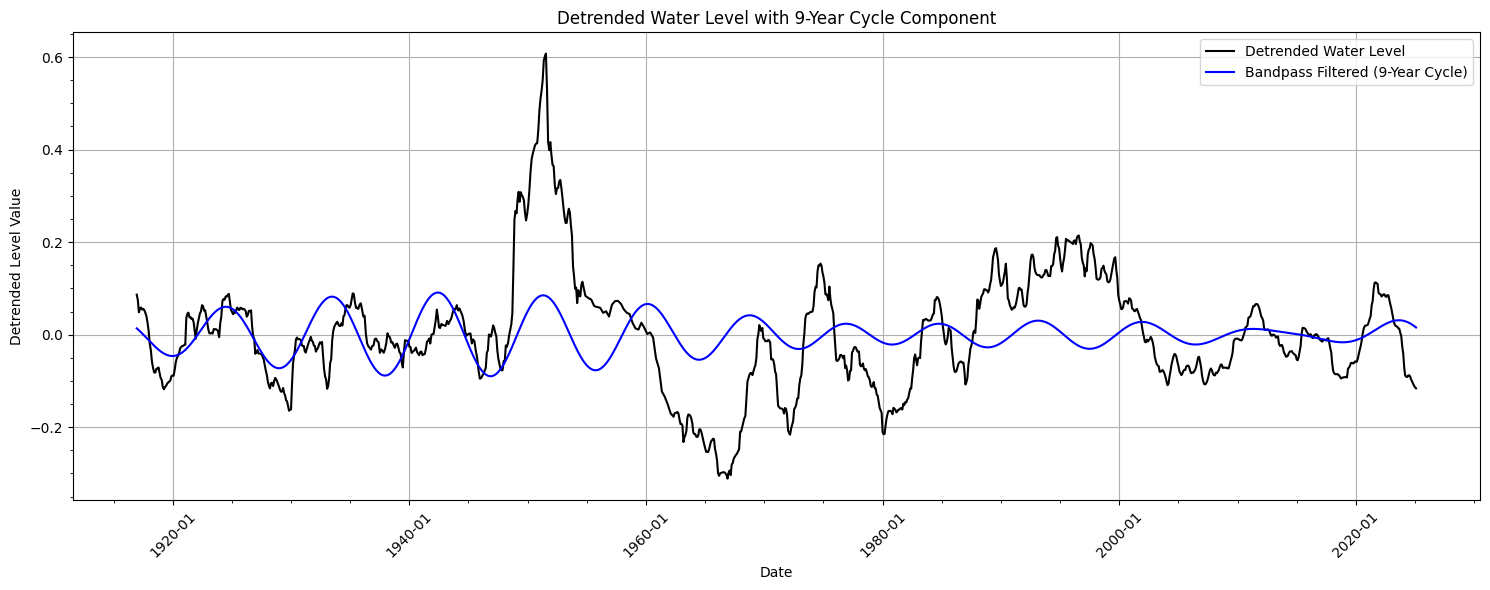

In [ ]:

# Bandpass filter for Water Level: 9-Year Cycle
low_freq_level = level_cycles['9-Year'] - delta_freq
high_freq_level = level_cycles['9-Year'] + delta_freq
filtered_x_level, filtered_signal_level = bandpass_filter(ts_level, detrend_level, [low_freq_level, high_freq_level])

plot_ts_dt_level = num_to_datetime(ts_level, first_date_dt)
plot_filtered_x_dt_level = num_to_datetime(filtered_x_level, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_level, detrend_level, 'k-', label='Detrended Water Level')
plt.plot(plot_filtered_x_dt_level, filtered_signal_level, 'b-', label='Bandpass Filtered (9-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Level Value')
plt.title('Detrended Water Level with 9-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


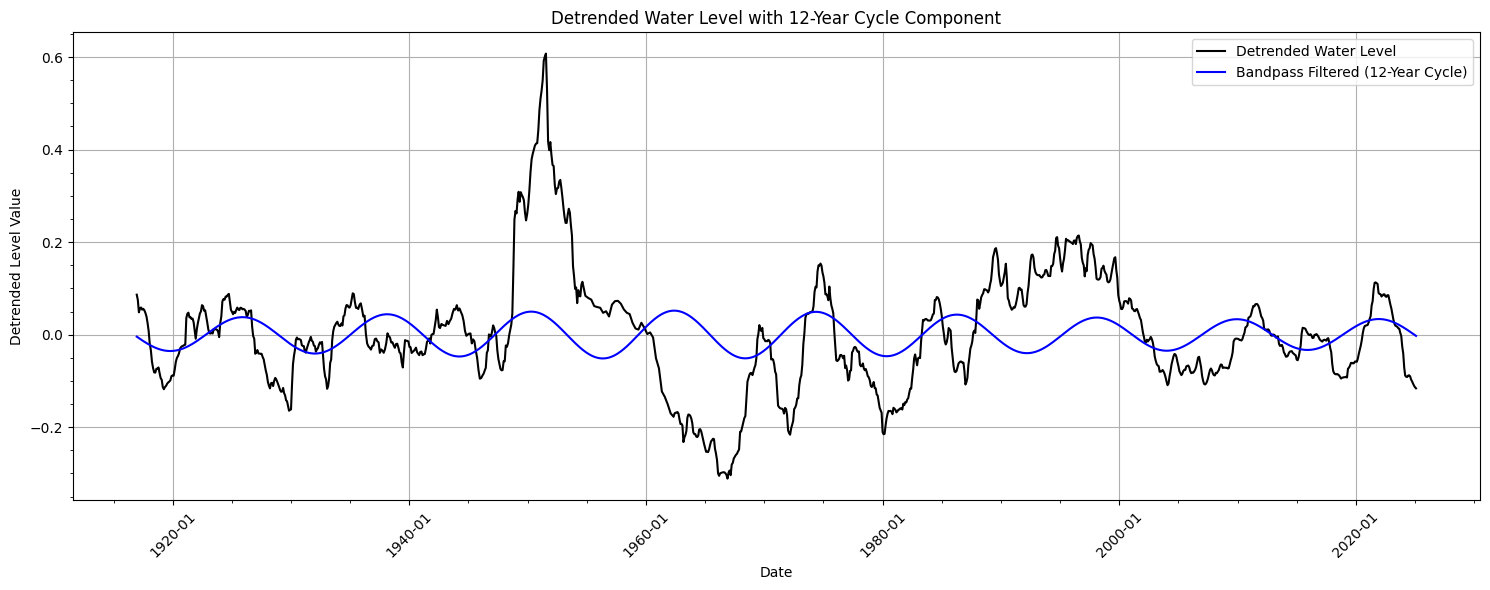

In [ ]:

# Bandpass filter for Water Level: 12-Year Cycle
low_freq_level = level_cycles['12-Year'] - delta_freq
high_freq_level = level_cycles['12-Year'] + delta_freq
filtered_x_level, filtered_signal_level = bandpass_filter(ts_level, detrend_level, [low_freq_level, high_freq_level])

plot_ts_dt_level = num_to_datetime(ts_level, first_date_dt)
plot_filtered_x_dt_level = num_to_datetime(filtered_x_level, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_level, detrend_level, 'k-', label='Detrended Water Level')
plt.plot(plot_filtered_x_dt_level, filtered_signal_level, 'b-', label='Bandpass Filtered (12-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Level Value')
plt.title('Detrended Water Level with 12-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


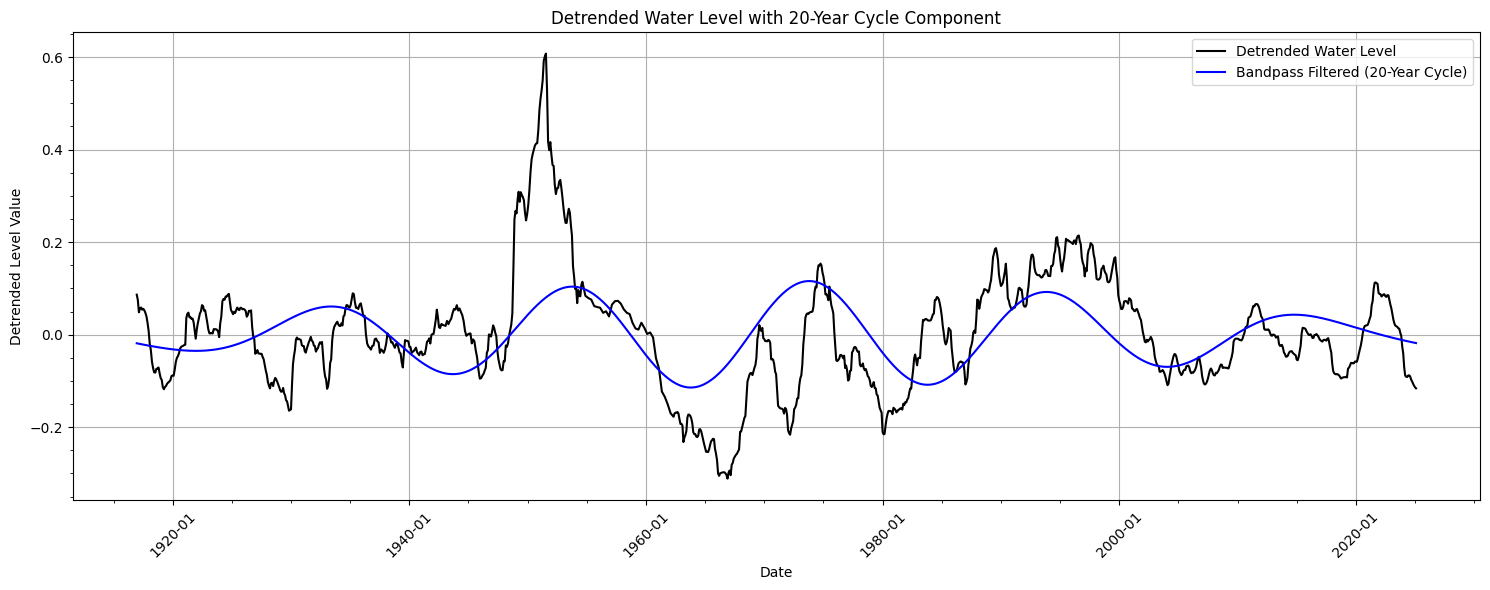

In [ ]:

# Bandpass filter for Water Level: 20-Year Cycle
low_freq_level = level_cycles['20-Year'] - delta_freq
high_freq_level = level_cycles['20-Year'] + delta_freq
filtered_x_level, filtered_signal_level = bandpass_filter(ts_level, detrend_level, [low_freq_level, high_freq_level])

plot_ts_dt_level = num_to_datetime(ts_level, first_date_dt)
plot_filtered_x_dt_level = num_to_datetime(filtered_x_level, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_level, detrend_level, 'k-', label='Detrended Water Level')
plt.plot(plot_filtered_x_dt_level, filtered_signal_level, 'b-', label='Bandpass Filtered (20-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Level Value')
plt.title('Detrended Water Level with 20-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


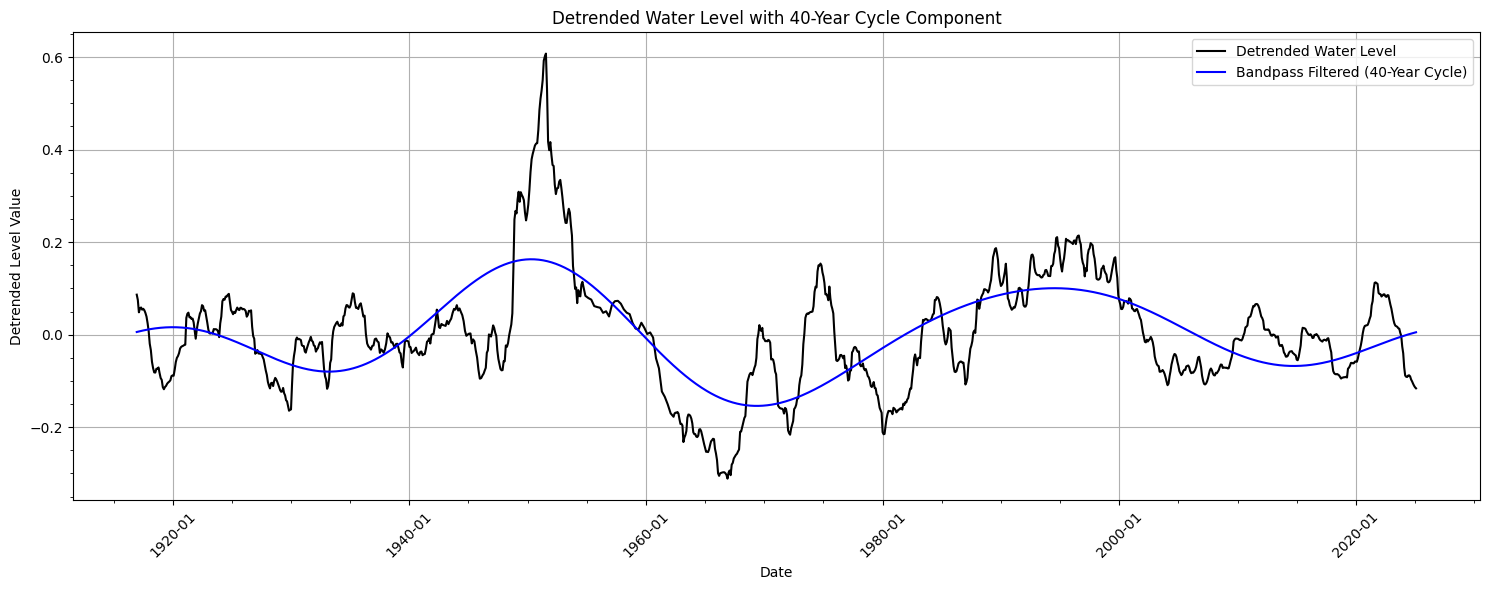

In [ ]:

# Bandpass filter for Water Level: 40-Year Cycle
low_freq_level = level_cycles['40-Year'] - delta_freq
high_freq_level = level_cycles['40-Year'] + delta_freq
filtered_x_level, filtered_signal_level = bandpass_filter(ts_level, detrend_level, [low_freq_level, high_freq_level])

plot_ts_dt_level = num_to_datetime(ts_level, first_date_dt)
plot_filtered_x_dt_level = num_to_datetime(filtered_x_level, first_date_dt)

plt.figure(figsize=(15, 6))
plt.plot(plot_ts_dt_level, detrend_level, 'k-', label='Detrended Water Level')
plt.plot(plot_filtered_x_dt_level, filtered_signal_level, 'b-', label='Bandpass Filtered (40-Year Cycle)')
plt.xlabel('Date')
plt.ylabel('Detrended Level Value')
plt.title('Detrended Water Level with 40-Year Cycle Component')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Reflections
Lee:

Khai:

Juliet:
In addition to my role as an analyst, I also had to complete my deputy role as the data steward. From the some of the ideas I came up with in the planning session, I decided to go with 'Current' for our topic. I found a big database from BOM where I could choose to look at data from different water bodies. I then read in the files and cleaned and combined them to only include relevant information. From some initial coding and experimentation of the data, I realised it was too noisy. To help combat this, I decided to do a monthly mean instead of daily to reduce the amount of data and then created a moving average for both the water discharge and level. From there I used the calculate moving averages to use the fouier transform. I then found frequency points that matched yearly cycles, changing the limits and creating multiple graphs to see different points in the data. I then used these frequencies and the bandpass function to overlay them on the detrended data.


Binyao:

Kedi: